# Prueba de Meteostat para Uruguay

Objetivo: ver si Meteostat sirve para conseguir datos meteorologicos **diarios medidos en estaciones reales** de Uruguay entre 2017-01-01 y 2026-09-20.

Es solo una prueba: no se guarda nada en S3.

## 1. Instalar e importar

In [1]:
# %pip install meteostat
# ya esta agregado al proyecto con: uv add meteostat

In [2]:
import meteostat
import pandas as pd
import matplotlib.pyplot as plt

meteostat.__version__

'2.1.5'

La version instalada es la **2.x**, que tiene una API distinta a la 1.x (ya no hay `Stations().region()` ni la clase `Daily(...)`).

En la 2.x se usan funciones: `stations.query(...)`, `stations.nearby(...)` y `daily(estacion, inicio, fin)`.

In [3]:
from datetime import datetime
from meteostat import stations, daily, Point, Provider

INICIO = datetime(2017, 1, 1)
FIN = datetime(2026, 9, 20)

## 2. Estaciones de Uruguay

El catalogo de estaciones viene en una base SQLite local, asi que la lista se saca con SQL.

`daily_start` / `daily_end` los armo desde la tabla `inventory`, quedandome solo con los proveedores **medidos** (`ghcnd` diario, `isd_lite` y `metar` horarios). Dejo afuera `metno_forecast` y `dwd_mosmix` porque son modelo/pronostico.

In [4]:
sql_uy = """
SELECT s.id,
       n.name,
       s.latitude,
       s.longitude,
       s.elevation,
       MIN(i.start) AS daily_start,
       MAX(i.end)   AS daily_end
FROM stations s
LEFT JOIN names n
       ON n.station = s.id AND n.language = 'en'
LEFT JOIN inventory i
       ON i.station = s.id AND i.provider IN ('ghcnd', 'isd_lite', 'metar')
WHERE s.country = 'UY'
GROUP BY s.id
ORDER BY n.name
"""

estaciones_uy = stations.query(sql_uy, index_col="id")
print(estaciones_uy.shape)
estaciones_uy

(21, 6)


,name,latitude,longitude,elevation,daily_start,daily_end
id,,,,,,
86330,Artigas,-30.3833,-56.5000,123,1949-01-02,2026-09-18
86315,Bella Union,-30.2667,-57.5833,54,1981-01-01,2025-12-02
86580,Carrasco,-34.8333,-56.0000,32,1949-01-01,2026-09-19
86560,Colonia,-34.4500,-57.8333,23,1949-01-01,2026-09-19
86530,Durazno,-33.3500,-56.5000,93,1949-01-01,2026-09-19
86545,Florida,-34.0667,-56.2333,97,1995-04-01,2025-08-24
86586,Laguna Del Sauce / Pan de Azúcar,-34.8600,-55.0967,28,2001-09-15,2022-09-29
SULS0,Maldonado,-34.8667,-55.1000,30,1990-10-18,2026-09-20
SUPE0,Maldonado,-34.9167,-54.9167,15,1975-11-18,2003-11-20


### Cuales cubren realmente 2017-2026

Me quedo con las que empiezan antes de 2017 y siguen midiendo hasta (casi) hoy.

In [5]:
con_datos = estaciones_uy[
    (estaciones_uy["daily_start"] <= "2017-01-01")
    & (estaciones_uy["daily_end"] >= "2026-09-01")
]

print(con_datos.shape)
con_datos

(10, 6)


,name,latitude,longitude,elevation,daily_start,daily_end
id,,,,,,
86330,Artigas,-30.3833,-56.5000,123,1949-01-02,2026-09-18
86580,Carrasco,-34.8333,-56.0000,32,1949-01-01,2026-09-19
86560,Colonia,-34.4500,-57.8333,23,1949-01-01,2026-09-19
86530,Durazno,-33.3500,-56.5000,93,1949-01-01,2026-09-19
SULS0,Maldonado,-34.8667,-55.1000,30,1990-10-18,2026-09-20
86575,Melilla,-34.7833,-56.2500,53,1975-04-01,2026-09-19
86440,Melo,-32.3667,-54.2167,100,1949-01-01,2026-09-19
86430,Paysandu,-32.3333,-58.0333,61,1935-01-01,2026-09-19
86350,Rivera,-30.8833,-55.5333,205,1949-01-01,2026-09-19


## 3. Mis puntos

Son los centroides de las 4 zonas seleccionadas del proyecto (`oan_gems_seleccion.geojson`).

In [6]:
PUNTOS = {
    "LDS": (-34.8027, -55.0811),
    "RDP-MONTES": (-34.2111, -58.0985),
    "RN-UPM1": (-33.1167, -58.2651),
    "RN-UPM2": (-32.8383, -56.5878),
}

PUNTOS

{'LDS': (-34.8027, -55.0811),
 'RDP-MONTES': (-34.2111, -58.0985),
 'RN-UPM1': (-33.1167, -58.2651),
 'RN-UPM2': (-32.8383, -56.5878)}

## 4. Estacion mas cercana a cada punto

`stations.nearby` devuelve las estaciones ordenadas por distancia (en metros). Filtro por las que tienen datos diarios en 2017-2026 y me quedo con la primera.

In [7]:
filas = []

for nombre, (lat, lon) in PUNTOS.items():
    cercanas = stations.nearby(Point(lat, lon), radius=500000, limit=100)
    cercanas = cercanas[cercanas.index.isin(con_datos.index)]
    id_estacion = cercanas.index[0]

    filas.append({
        "punto": nombre,
        "estacion_id": id_estacion,
        "estacion": cercanas.loc[id_estacion, "name"],
        "distancia_km": round(cercanas.loc[id_estacion, "distance"] / 1000, 1),
        "daily_start": con_datos.loc[id_estacion, "daily_start"],
        "daily_end": con_datos.loc[id_estacion, "daily_end"],
    })

cercanas_por_punto = pd.DataFrame(filas)
cercanas_por_punto["mas_de_50km"] = cercanas_por_punto["distancia_km"] > 50
cercanas_por_punto

,punto,estacion_id,estacion,distancia_km,daily_start,daily_end,mas_de_50km
0,LDS,SULS0,Maldonado,7.3,1990-10-18,2026-09-20,False
1,RDP-MONTES,86560,Colonia,36.0,1949-01-01,2026-09-19,False
2,RN-UPM1,86430,Paysandu,89.8,1935-01-01,2026-09-19,True
3,RN-UPM2,86530,Durazno,57.5,1949-01-01,2026-09-19,True


Las que quedan lejos:

In [8]:
cercanas_por_punto[cercanas_por_punto["mas_de_50km"]]

,punto,estacion_id,estacion,distancia_km,daily_start,daily_end,mas_de_50km
2,RN-UPM1,86430,Paysandu,89.8,1935-01-01,2026-09-19,True
3,RN-UPM2,86530,Durazno,57.5,1949-01-01,2026-09-19,True


### Mapa: mis puntos y las estaciones asignadas

Armo una tabla con las dos coordenadas (punto y estacion) para poder dibujarlas juntas.

In [9]:
import geopandas as gpd
import contextily as cx
from shapely.geometry import LineString

mapa = cercanas_por_punto.copy()
mapa["punto_lat"] = [PUNTOS[n][0] for n in mapa["punto"]]
mapa["punto_lon"] = [PUNTOS[n][1] for n in mapa["punto"]]
mapa["est_lat"] = con_datos.loc[mapa["estacion_id"], "latitude"].values
mapa["est_lon"] = con_datos.loc[mapa["estacion_id"], "longitude"].values

mapa[["punto", "punto_lat", "punto_lon", "estacion", "est_lat", "est_lon", "distancia_km"]]

,punto,punto_lat,punto_lon,estacion,est_lat,est_lon,distancia_km
0,LDS,-34.8027,-55.0811,Maldonado,-34.8667,-55.1000,7.3
1,RDP-MONTES,-34.2111,-58.0985,Colonia,-34.4500,-57.8333,36.0
2,RN-UPM1,-33.1167,-58.2651,Paysandu,-32.3333,-58.0333,89.8
3,RN-UPM2,-32.8383,-56.5878,Durazno,-33.3500,-56.5000,57.5


In [10]:
gdf_puntos = gpd.GeoDataFrame(
    mapa,
    geometry=gpd.points_from_xy(mapa["punto_lon"], mapa["punto_lat"]),
    crs="EPSG:4326",
)

gdf_estaciones = gpd.GeoDataFrame(
    mapa,
    geometry=gpd.points_from_xy(mapa["est_lon"], mapa["est_lat"]),
    crs="EPSG:4326",
)

gdf_lineas = gpd.GeoDataFrame(
    mapa,
    geometry=[
        LineString([(r["punto_lon"], r["punto_lat"]), (r["est_lon"], r["est_lat"])])
        for _, r in mapa.iterrows()
    ],
    crs="EPSG:4326",
)

Los circulos de 50 km los hago en UTM 21S (EPSG:32721), que es metrico, y despues paso todo a 3857 para el basemap.

In [11]:
gdf_buffers = gdf_puntos.to_crs(32721).buffer(50_000).to_frame("geometry").set_crs(32721)

puntos_3857 = gdf_puntos.to_crs(3857)
estaciones_3857 = gdf_estaciones.to_crs(3857)
lineas_3857 = gdf_lineas.to_crs(3857)
buffers_3857 = gdf_buffers.to_crs(3857)

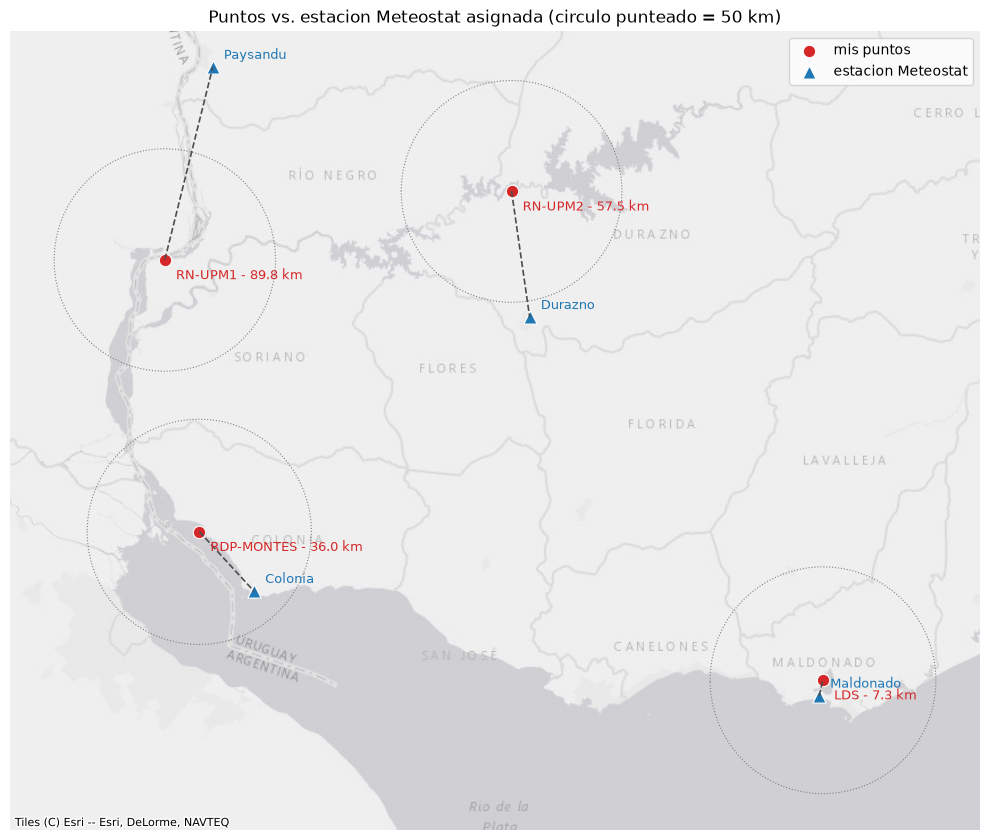

In [12]:
fig, ax = plt.subplots(figsize=(10, 11))

buffers_3857.plot(ax=ax, facecolor="none", edgecolor="0.5", linewidth=0.8, linestyle=":")
lineas_3857.plot(ax=ax, color="0.3", linewidth=1.2, linestyle="--")
puntos_3857.plot(ax=ax, markersize=80, color="tab:red", edgecolor="white", linewidth=0.8, label="mis puntos")
estaciones_3857.plot(ax=ax, markersize=90, marker="^", color="tab:blue", edgecolor="white", linewidth=0.8, label="estacion Meteostat")

# la distancia va pegada al nombre del punto: si la estacion esta muy cerca (LDS),
# una etiqueta en el medio de la linea se superpone con el nombre de la estacion
for (_, r), geo_p, geo_e in zip(mapa.iterrows(), puntos_3857.geometry, estaciones_3857.geometry):
    ax.annotate(f"{r['punto']} - {r['distancia_km']} km", (geo_p.x, geo_p.y), xytext=(8, -14), textcoords="offset points", fontsize=9, color="tab:red")
    ax.annotate(r["estacion"], (geo_e.x, geo_e.y), xytext=(8, 6), textcoords="offset points", fontsize=9, color="tab:blue")

cx.add_basemap(ax, source=cx.providers.Esri.WorldGrayCanvas)
ax.set_axis_off()
ax.legend(loc="upper right")
ax.set_title("Puntos vs. estacion Meteostat asignada (circulo punteado = 50 km)")
plt.tight_layout()
plt.show()

### Todas las estaciones de Uruguay con datos 2017-2026

Para ver que tan rala es la red y si habia alguna alternativa mas cerca.

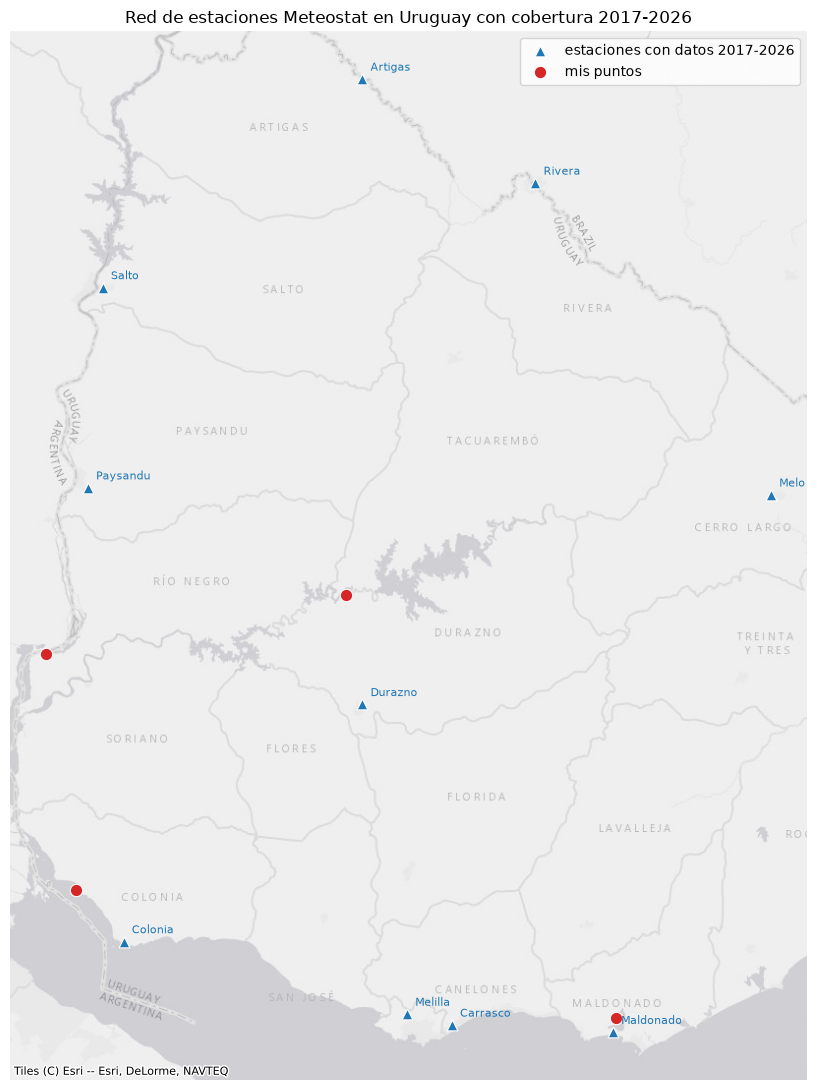

In [13]:
gdf_red = gpd.GeoDataFrame(
    con_datos,
    geometry=gpd.points_from_xy(con_datos["longitude"], con_datos["latitude"]),
    crs="EPSG:4326",
).to_crs(3857)

fig, ax = plt.subplots(figsize=(10, 11))

gdf_red.plot(ax=ax, markersize=60, marker="^", color="tab:blue", edgecolor="white", linewidth=0.8, label="estaciones con datos 2017-2026")
puntos_3857.plot(ax=ax, markersize=80, color="tab:red", edgecolor="white", linewidth=0.8, label="mis puntos")

for (nombre, r), geo in zip(gdf_red.iterrows(), gdf_red.geometry):
    ax.annotate(r["name"], (geo.x, geo.y), xytext=(6, 6), textcoords="offset points", fontsize=8, color="tab:blue")

cx.add_basemap(ax, source=cx.providers.Esri.WorldGrayCanvas)
ax.set_axis_off()
ax.legend(loc="upper right")
ax.set_title("Red de estaciones Meteostat en Uruguay con cobertura 2017-2026")
plt.tight_layout()
plt.show()

## 5. Analisis del primer punto

In [14]:
punto_1 = cercanas_por_punto.iloc[0]
punto_1

punto                  LDS
estacion_id          SULS0
estacion         Maldonado
distancia_km           7.3
daily_start     1990-10-18
daily_end       2026-09-20
mas_de_50km          False
Name: 0, dtype: object

### Descarga de los datos diarios

En meteostat 2.x el proveedor por defecto de `daily()` son las observaciones diarias de estacion (`Provider.DAILY`). Lo paso explicito para dejar claro que **no** entra relleno de modelo (`metno_forecast`, `dwd_mosmix`).

In [15]:
serie = daily(
    punto_1["estacion_id"],
    INICIO,
    FIN,
    providers=[Provider.DAILY],
)

df = serie.fetch()
print(df.shape)

(3466, 11)


In [16]:
df.head()

,temp,tmin,tmax,rhum,prcp,snwd,wspd,wpgt,pres,tsun,cldc
time,,,,,,,,,,,
2017-01-01,25.0,22.0,30.0,84,<NA>,<NA>,15.7,<NA>,<NA>,<NA>,<NA>
2017-01-02,22.2,19.0,26.0,71,<NA>,<NA>,19.9,<NA>,<NA>,<NA>,<NA>
2017-01-03,21.1,<NA>,<NA>,89,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2017-01-05,21.6,<NA>,<NA>,73,<NA>,<NA>,19.5,<NA>,<NA>,<NA>,<NA>
2017-01-06,19.9,<NA>,<NA>,63,<NA>,<NA>,13.7,<NA>,<NA>,<NA>,<NA>


In [17]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 3466 entries, 2017-01-01 to 2026-09-20
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   temp    3461 non-null   Float64
 1   tmin    2948 non-null   Float64
 2   tmax    2948 non-null   Float64
 3   rhum    3459 non-null   UInt8  
 4   prcp    2064 non-null   Float64
 5   snwd    0 non-null      UInt16 
 6   wspd    3446 non-null   Float64
 7   wpgt    0 non-null      Float64
 8   pres    2417 non-null   Float64
 9   tsun    0 non-null      UInt16 
 10  cldc    1481 non-null   UInt8  
dtypes: Float64(7), UInt16(2), UInt8(2)
memory usage: 274.2 KB


### Porcentaje de faltantes por columna

In [18]:
faltantes = (df.isna().mean() * 100).round(1).sort_values()
faltantes

temp      0.1
rhum      0.2
wspd      0.6
tmin     14.9
tmax     14.9
pres     30.3
prcp     40.5
cldc     57.3
wpgt    100.0
snwd    100.0
tsun    100.0
dtype: float64

### Dias con datos por anio

Cuento los dias que tienen temperatura media (`temp`) y los que tienen precipitacion (`prcp`), para ver si hay huecos.

In [19]:
por_anio = pd.DataFrame({
    "dias_en_el_df": df.groupby(df.index.year).size(),
    "dias_con_temp": df["temp"].notna().groupby(df.index.year).sum(),
    "dias_con_prcp": df["prcp"].notna().groupby(df.index.year).sum(),
})

por_anio

,dias_en_el_df,dias_con_temp,dias_con_prcp
time,,,
2017,318,318,0
2018,354,353,0
2019,348,348,0
2020,359,355,0
2021,365,365,364
2022,365,365,365
2023,365,365,365
2024,366,366,353
2025,365,365,357


### Graficos

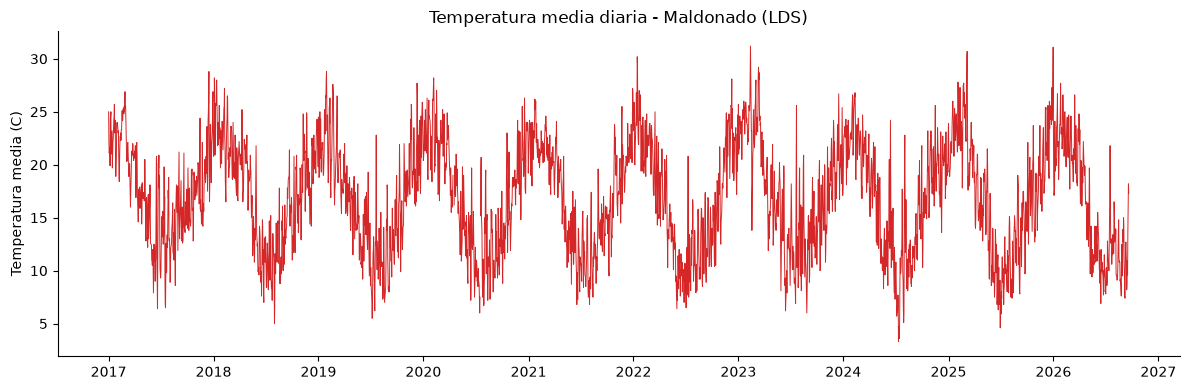

In [20]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, df["temp"], linewidth=0.7, color="tab:red")
ax.set_ylabel("Temperatura media (C)")
ax.set_title(f"Temperatura media diaria - {punto_1['estacion']} ({punto_1['punto']})")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

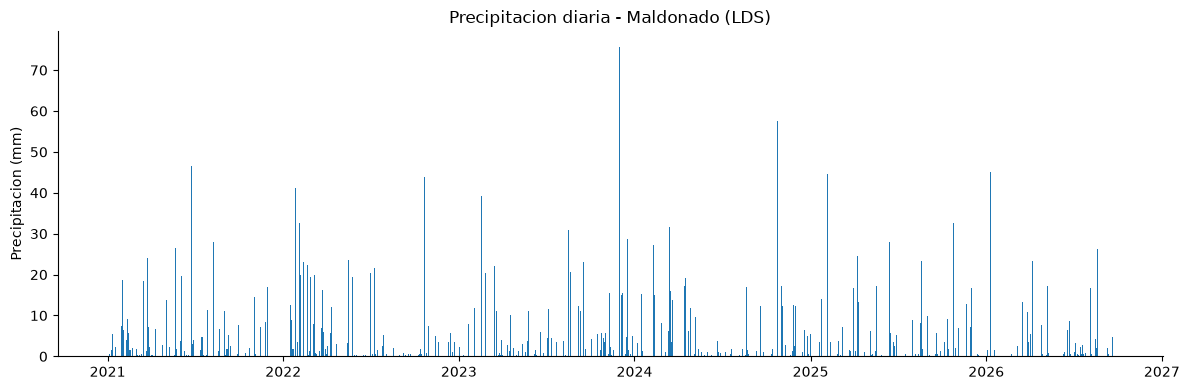

In [21]:
prcp = df["prcp"].dropna().astype(float)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(prcp.index, prcp.values, width=1.0, color="tab:blue")
ax.set_ylabel("Precipitacion (mm)")
ax.set_title(f"Precipitacion diaria - {punto_1['estacion']} ({punto_1['punto']})")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Conclusion

**Meteostat sirve, con reservas.**

- **Cobertura temporal**: la estacion del primer punto (Maldonado, `SULS0`, a 7.3 km de LDS) cubre 2017-2026 entero. Los huecos estan al principio: 2017 tiene 318 dias y 2019 348; de 2021 en adelante esta practicamente todo.
- **Variables que sirven**: `temp` (0.1% faltante), `rhum` (0.2%) y `wspd` (0.6%) son las mas solidas. `tmin` / `tmax` tienen ~15% de faltantes y `pres` ~30%.
- **Precipitacion**: `prcp` figura con 40.5% de faltantes, pero no esta repartido: **2017-2020 no tiene ni un dia de lluvia cargado** y recien arranca en 2021 (de ahi en mas casi completo). Si necesitamos precipitacion desde 2017 hay que ir a INUMET.
- **Variables vacias**: `snwd`, `wpgt` y `tsun` vienen 100% NaN. `cldc` tiene 57.3% de faltantes.
- **Distancia**: LDS (7.3 km) y RDP-MONTES (36 km) tienen estacion cerca. RN-UPM1 (Paysandu, 89.8 km) y RN-UPM2 (Durazno, 57.5 km) quedan a mas de 50 km, asi que ahi el dato meteorologico representa peor la zona.
- **Ojo con el catalogo**: la estacion mas cercana a LDS es `86586` (Laguna del Sauce, 6.5 km) pero corta en 2022, por eso el filtro de cobertura la descarta.